# Model-free control

- On-Policy Monte-Carlo Control
- On-Policy Temporal-Diﬀerence Learning
- Oﬀ-Policy Learning

**Model-free prediction**

-> Estimate the value function of an unknown MDP

**Model-free control**

-> Optimise value function of an unknown MDP

For most problems:

- MDP model is unknown, but experience can be sampled
- MDP model is known, but too big to use, except by samples


**On-policy** learning

- "learn on the job"
- learn about policy $\pi$ from experience sampled from $\pi$

**Off-policy** learning

- "Look over someone's shoulder"
- Learn about policy $\pi$ from experience sampled from $\mu$


## Introduction

### Generalized policy iteration (refresher)

<img src="../image-92.png" width="600px"/>

### Generalized policy iteration with monte-carlo evaluation

<img src="../image-93.png" width="600px"/>



### Generalized policy iteration (refresher)

<img src="../image-92.png" width="600px"/>

Model-Free Policy Iteration Using Action-Value Function

- Greedy policy improvement over $V(s)$ requires model of MDP

$$\pi'(s) = \argmax_{a \in \mathcal{A}} \mathcal{R}_s^a + \mathcal{P}_{ss'}^a V(s')$$

to evaluate action a from state s, need immediate reward and transition probability to next state, so a model that we don't have

- Greedy policy improvement over $Q(s, a)$ is model-free

$$\pi'(s) = \argmax_{a \in \mathcal{A}} Q(s, a)$$

Q(s,a) encode "how good is action a from state s" -> juste juste need argmax of Q, no model needed. 

Q-functions are more practical because you can improve policy without knowing env dynamics.

-> To improve a policy greedily, pick the action that looks best from the current state.


### Generalised Policy Iteration with Action-Value Function


<img src="../image-94.png" width="600px"/>

### $\epsilon$-Greedy exploration

- Simplest idea for ensuring continual exploration
- All m actions are tried with non-zero probability
- With probability 1−ϵ choose the greedy action
- With probability ϵ choose an action at random

$$
\pi(a|s) = \begin{cases} \epsilon/m + 1 - \epsilon & \text{if } a^* = \underset{a \in \mathcal{A}}{\argmax} \ Q(s, a) \\ \epsilon/m & \text{otherwise} \end{cases}
$$

When policy is optimal, we always use greedy action. The goal is to find the greedy action.  Exploration is only to learn



### $\epsilon$-Greedy policy improvement

**Theorem**

For any $\epsilon$-greedy policy $\pi$, the $\epsilon$-greedy policy $\pi'$ with respect to $q_\pi$ is an improvement, $v_{\pi'}(s) \geq v_\pi(s)$*

-> Greedifying an ε-greedy policy always improves it (or keeps it the same).

- You have policy π (ε-greedy), and you build π' by acting greedier with respect to π's Q-values
- The proof shows that the value of following π' from any state is at least as good as following π
-----
Proof:

$$
\begin{aligned}
q_\pi(s, \pi'(s)) &= \sum_{a \in \mathcal{A}} \pi'(a|s) q_\pi(s, a) \\
&= \epsilon/m \sum_{a \in \mathcal{A}} q_\pi(s, a) + (1 - \epsilon) \max_{a \in \mathcal{A}} q_\pi(s, a) \\
&\geq \epsilon/m \sum_{a \in \mathcal{A}} q_\pi(s, a) + (1 - \epsilon) \sum_{a \in \mathcal{A}} \frac{\pi(a|s) - \epsilon/m}{1 - \epsilon} q_\pi(s, a) \\
&= \sum_{a \in \mathcal{A}} \pi(a|s) q_\pi(s, a) = v_\pi(s)
\end{aligned}
$$

Therefore from policy improvement theorem, $v_{\pi'}(s) \geq v_\pi(s)$

line 2/3: max is replaced by weighted sum using the greedy part of $\pi$ so

$$\max_{a} q_\pi(s,a) \geq \sum_a \frac{\pi(a|s) - \epsilon/m}{1-\epsilon} q_\pi(s,a)$$

the best action's value ≥ the weighted average value under π's greedy part. Obvious, since max ≥ average.


### Monte-carlo policy iteration

- Policy evaluation:  Monte-Carlo policy evaluation, $Q=q_\pi$ 
- Policy improvement: ϵ-greedy policy improvement

### Monte-carlo control

**On every episode**

So we don't wait for many episodes to evaluate and update policy

- Policy evaluation: Monte-Carlo policy evaluation, $Q \approx q_\pi$, 
- Policy improvement: ϵ-greedy policy improvement


### GLIE

**Definition**

*Greedy in the Limit with Infinite Exploration* (GLIE):  is a condition that guarantees Monte Carlo control converges to the optimal policy. It requires two things:

- All state-action pairs are explored infinitely many times (infinite exploration),

$$\lim_{k \to \infty} N_k(s, a) = \infty$$

- The policy converges on a greedy policy (eventual greediness),

$$\lim_{k \to \infty} \pi_k(a|s) = \mathbf{1}(a = \underset{a' \in \mathcal{A}}{\argmax} \ Q_k(s, a'))$$

The policy must become fully greedy in the limit — so it actually exploits what it learned.

**The tension**: exploration vs exploitation

- You need enough exploration to learn accurate Q-values
- But you need to stop exploring eventually to act optimally

For example, $\epsilon$-greedy is GLIE if $\epsilon$ reduces to zero at $\epsilon_k = \frac{1}{k}$, (We apply a schedule to $\epsilon$): 

- $\epsilon_k  \to 0$, so policy becomes greedy
- $\epsilon_k  \to 0$ decreases slowly enough that all pairs are visited infinitely often




#### GLIE Monte-carlo

- Sample $k$th episode using $\pi$: $\{S_1, A_1, R_2, ..., S_T\} \sim \pi$
- For each state $S_t$ and action $A_t$ in the episode,

$$N(S_t, A_t) \leftarrow N(S_t, A_t) + 1$$

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \frac{1}{N(S_t, A_t)}\left(G_t - Q(S_t, A_t)\right)$$

- Improve policy based on new action-value function

$$\epsilon \leftarrow 1/k$$

$$\pi \leftarrow \epsilon\text{-greedy}(Q)$$

**Theorem**

*GLIE Monte-Carlo control converges to the optimal action-value function, $Q(s,a) \to q_*(s,a)$*

**Explanation**

This is GLIE Monte-Carlo control — the full algorithm:

1. **Run episode** using current $\epsilon$-greedy policy, collect trajectory
2. **Update Q** for each visited $(S_t, A_t)$: incremental mean update — $Q$ moves toward the return $G_t$ (actual cumulative reward from that point)
3. **Shrink $\epsilon$** as $1/k$ — exploration decreases each episode
4. **Greedify** — update policy to be $\epsilon$-greedy w.r.t. new $Q$

Because $\epsilon = 1/k$ satisfies GLIE conditions, the theorem guarantees $Q \to q_*$ — you learn the optimal action-values.

In [1]:
import numpy as np
import pandas as pd
import random


# ── Card helpers ─────────────────────────────────────────────────────
def get_card():
    card = random.randint(1, 13)
    return min(card, 10)


def get_score(hand):
    """Returns (sum, has_usable_ace)"""
    score = sum(hand)
    usable_ace = False
    if 1 in hand and score + 10 <= 21:
        score += 10
        usable_ace = True
    return score, usable_ace


# ── Environment ──────────────────────────────────────────────────────
class BlackjackEnv:
    """Blackjack environment. Returns states as (player_sum, dealer_card, usable_ace)."""

    def reset(self):
        """Deal a new hand and return the initial state."""
        self.player_hand = [get_card(), get_card()]
        self.dealer_up_card = get_card()

        # Auto-twist until decision zone [12..21]
        p_sum, usable_ace = get_score(self.player_hand)
        while p_sum < 12:
            self.player_hand.append(get_card())
            p_sum, usable_ace = get_score(self.player_hand)

        self.done = False
        return (p_sum, self.dealer_up_card, usable_ace)

    def step(self, action):
        """Take an action ('twist' or 'stick'). Returns (next_state, reward, done)."""
        if action == "twist":
            self.player_hand.append(get_card())
            p_sum, usable_ace = get_score(self.player_hand)

            if p_sum > 21:
                self.done = True
                return None, -1.0, True

            while p_sum < 12:
                self.player_hand.append(get_card())
                p_sum, usable_ace = get_score(self.player_hand)

            if p_sum > 21:
                self.done = True
                return None, -1.0, True

            next_state = (p_sum, self.dealer_up_card, usable_ace)
            return next_state, 0.0, False

        else:  # stick -> dealer plays, episode ends
            dealer_hand = [self.dealer_up_card, get_card()]
            d_sum, _ = get_score(dealer_hand)
            while d_sum < 17:
                dealer_hand.append(get_card())
                d_sum, _ = get_score(dealer_hand)

            p_final, _ = get_score(self.player_hand)
            if d_sum > 21 or p_final > d_sum:
                reward = 1.0
            elif p_final == d_sum:
                reward = 0.0
            else:
                reward = -1.0

            self.done = True
            return None, reward, True

### GLIE Monte-Carlo Control — Blackjack

Apply GLIE MC control to the Blackjack environment:

- **State**: `(player_sum, dealer_card, usable_ace)` — player sum ∈ [12, 21], dealer showing ∈ [1, 10], usable ace ∈ {True, False}
- **Actions**: `twist` (hit) or `stick` (stand)
- **Q-table**: shape `(10, 10, 2, 2)` — indexed by `(player_sum - 12, dealer_card - 1, usable_ace, action)`
- **ε schedule**: $\epsilon_k = 1/k$ (GLIE condition)

The algorithm learns $Q(s, a) \to q_*(s, a)$ and derives the optimal policy $\pi^*$.

In [2]:
import matplotlib.pyplot as plt

ACTIONS = ["twist", "stick"]

# ── Helpers ──────────────────────────────────────────────────────────
def state_to_idx(state):
    """(player_sum, dealer_card, usable_ace) → numpy index tuple."""
    p_sum, d_card, u_ace = state
    return (p_sum - 12, d_card - 1, int(u_ace))


def epsilon_greedy_action(Q, state, epsilon):
    """Pick action via ε-greedy w.r.t. Q."""
    idx = state_to_idx(state)
    if np.random.random() < epsilon:
        return np.random.randint(len(ACTIONS))
    return int(np.argmax(Q[idx]))


# ── GLIE Monte-Carlo Control ────────────────────────────────────────
def glie_mc_control(n_episodes=500_000, gamma=1.0):
    # Q(player_sum, dealer_card, usable_ace, action)
    Q = np.zeros((10, 10, 2, len(ACTIONS)))
    N = np.zeros_like(Q)

    env = BlackjackEnv()

    for k in range(1, n_episodes + 1):
        epsilon = 1.0 / k

        # ── Generate episode using ε-greedy(Q) ──
        state = env.reset()
        episode = []  # list of (state, action, reward)

        done = False
        while not done:
            action = epsilon_greedy_action(Q, state, epsilon)
            next_state, reward, done = env.step(ACTIONS[action])
            episode.append((state, action, reward))
            if not done:
                state = next_state

        # ── Update Q for each first-visit (s, a) ──
        G = 0.0
        visited = set()
        for state, action, reward in reversed(episode):
            G = gamma * G + reward
            sa = (*state_to_idx(state), action)
            if sa not in visited:
                visited.add(sa)
                N[sa] += 1
                Q[sa] += (1.0 / N[sa]) * (G - Q[sa])

    return Q, N


Q, N = glie_mc_control(n_episodes=500_000, gamma=1.0)

# ── Derive greedy policy from Q ──────────────────────────────────────
policy = np.argmax(Q, axis=-1)  # shape (10, 10, 2): 0 = twist, 1 = stick

print("Training complete.")
print(f"States visited at least once: {int((N.sum(axis=-1) > 0).sum())} / {10*10*2}")


Training complete.
States visited at least once: 200 / 200


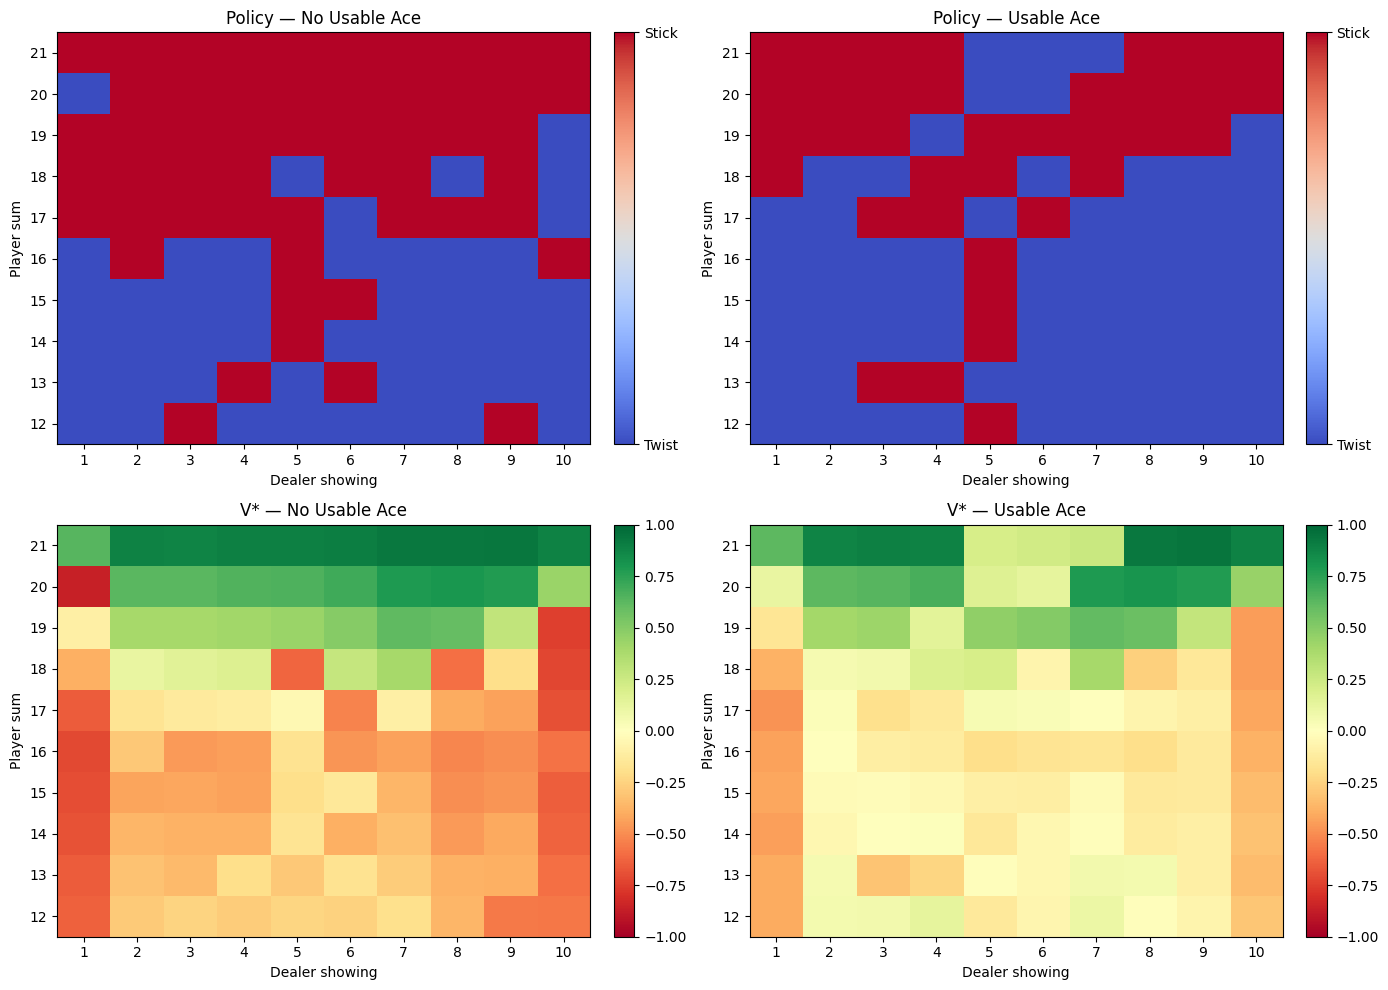

In [3]:
# ── Visualise learned policy & value function ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

titles = [
    "Policy — No Usable Ace",
    "Policy — Usable Ace",
    "V* — No Usable Ace",
    "V* — Usable Ace",
]

for col, u_ace in enumerate([0, 1]):
    # ── Policy heatmap ──
    ax = axes[0, col]
    im = ax.imshow(
        policy[:, :, u_ace],
        cmap="coolwarm",
        origin="lower",
        aspect="auto",
        vmin=0,
        vmax=1,
    )
    ax.set_title(titles[col])
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 1])
    cb.set_ticklabels(["Twist", "Stick"])

    # ── Value function heatmap: V*(s) = max_a Q(s, a) ──
    V_star = np.max(Q[:, :, u_ace, :], axis=-1)
    ax = axes[1, col]
    im = ax.imshow(
        V_star,
        cmap="RdYlGn",
        origin="lower",
        aspect="auto",
        vmin=-1,
        vmax=1,
    )
    ax.set_title(titles[2 + col])
    ax.set_xlabel("Dealer showing")
    ax.set_ylabel("Player sum")
    ax.set_xticks(range(10), [str(i) for i in range(1, 11)])
    ax.set_yticks(range(10), [str(i) for i in range(12, 22)])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()
